In [10]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/competitions/signate_mufgcup2024/notebooks


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from datetime import datetime
from sklearn.preprocessing import LabelEncoder

In [4]:
# configの読み込み
CONFIG_FILE = '../configs/config.yaml'
with open(CONFIG_FILE, encoding="utf-8") as file:
    yml = yaml.safe_load(file)

In [5]:
DIR_INPUT = yml["SETTING"]["DIR_INPUT"]
DIR_INTERIM = yml["SETTING"]["DIR_INTERIM"]
DIR_FEATURE = yml["SETTING"]["DIR_FEATURE"]
DIR_FIGURE = yml["SETTING"]["DIR_FIGURE"]
DIR_HOME = yml["SETTING"]["DIR_HOME"]
DIR_LOG = yml["SETTING"]["DIR_LOG"]
DIR_SUBMISSION = yml["SETTING"]["DIR_SUBMISSION"]
DIR_MODEL = yml["SETTING"]["DIR_MODEL"]
FILE_NAME_STATION = yml["SETTING"]["FILE_NAME_STATION"]
FILE_NAME_STATUS = yml["SETTING"]["FILE_NAME_STATUS"]
FILE_NAME_TRIP = yml["SETTING"]["FILE_NAME_TRIP"]
FILE_NAME_WEATHER = yml["SETTING"]["FILE_NAME_WEATHER"]

In [6]:
# 自作モジュールの読み込み
import sys
sys.path.append(DIR_HOME)
from src.util import Logger, Util

# データ読み込み

In [15]:
dict_dtype_station = {
    "station_id": "int64",
    "lat": "float64",
    "long": "float64",
    "dock_count": "int64",
    "city": "object",
    "installation_date": "object",
}
dict_dtype_status = {
    "id": "int64",
    "year": "int64",
    "month": "int64",
    "day": "int64",
    "hour": "int64",
    "station_id": "int64",
    "bikes_available": "float64",
    "predict": "int64",
}
dict_dtype_trip = {
    "trip_id": "int64",
    "duration": "int64",
    "start_date": "object",
    "start_station_id": "int64",
    "end_date": "object",
    "end_station_id": "int64",
    "bike_id": "int64",
    "subscription_type": "object",
}
dict_dtype_weather = {
    "date": "object",
    "max_temperature": "int64",
    "mean_temperature": "int64",
    "min_temperature": "int64",
    "max_dew_point": "int64",
    "mean_dew_point": "int64",
    "min_dew_point": "int64",
    "max_humidity": "int64",
    "mean_humidity": "int64",
    "min_humidity": "int64",
    "max_sea_level_pressure": "float64",
    "mean_sea_level_pressure": "float64",
    "min_sea_level_pressure": "float64",
    "max_visibility": "int64",
    "mean_visibility": "int64",
    "min_visibility": "int64",
    "max_wind_Speed": "int64",
    "mean_wind_speed": "int64",
    "precipitation": "float64",
    "cloud_cover": "int64",
    "events": "object",
    "wind_dir_degrees": "int64",
}

In [16]:
df_station = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATION), dtype=dict_dtype_station)
df_status = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_STATUS), dtype=dict_dtype_status)
df_trip = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_TRIP), dtype=dict_dtype_trip)
df_weather = pd.read_csv(os.path.join(DIR_INPUT, FILE_NAME_WEATHER), dtype=dict_dtype_weather)

# 前処理

In [17]:
def convert_datetime(df_station, df_status, df_trip, df_weather):
    df_station["installation_date"] = pd.to_datetime(df_station["installation_date"], format='%m/%d/%Y').dt.date
    df_status["datetime"] = pd.to_datetime(df_status[["year", "month", "day", "hour"]])
    df_trip["start_date"] = pd.to_datetime(df_trip["start_date"], format='%m/%d/%Y %H:%M')
    df_trip["end_date"] = pd.to_datetime(df_trip["end_date"], format='%m/%d/%Y %H:%M')
    df_weather["date"] = pd.to_datetime(df_weather["date"], format='%Y-%m-%d').dt.date

    return df_station, df_status, df_trip, df_weather

In [18]:
df_station, df_status, df_trip, df_weather = convert_datetime(df_station, df_status, df_trip, df_weather)

In [19]:
# データ出力
df_station.to_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_status.to_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_trip.to_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_weather.to_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

# 特徴量作成

In [ ]:
from pathlib import Path
from abc import ABCMeta, abstractmethod

In [ ]:
from time import time

def decorate(s: str, decoration=None):
    if decoration is None:
        decoration = '★' * 20

    return ' '.join([decoration, str(s), decoration])

class Timer:
    def __init__(self, logger=None, format_str='{:.3f}[s]', prefix=None, suffix=None, sep=' ', verbose=0):

        if prefix: format_str = str(prefix) + sep + format_str
        if suffix: format_str = format_str + sep + str(suffix)
        self.format_str = format_str
        self.logger = logger
        self.start = None
        self.end = None
        self.verbose = verbose

    @property
    def duration(self):
        if self.end is None:
            return 0
        return self.end - self.start

    def __enter__(self):
        self.start = time()

    def __exit__(self, exc_type, exc_val, exc_tb):
        self.end = time()
        if self.verbose is None:
            return
        out_str = self.format_str.format(self.duration)
        if self.logger:
            self.logger.info(out_str)
        else:
            print(out_str)

In [ ]:
class AbstractBaseBlock(metaclass=ABCMeta):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        self.use_cache = use_cache
        self.name = self.__class__.__name__
        self.cache_dir = Path(DIR_FEATURE)
        self.logger = logger
        self.seve_cache = save_cache
        self.use_cols = None

    # 内部状態の更新
    def fit(self, df_input: pd.DataFrame, y=None):
        pass

    # 変換処理
    @abstractmethod
    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        raise NotImplementedError()

    # 内部状態の更新と変換処理をまとめて行う
    def fit_transform(self, X: pd.DataFrame, y=None):
        self.fit(X, y)
        return self.transform(X)

    # 特徴量生成処理
    def create_feature(self, X, y=None, test=False, limit_date="yyyy-mm-dd") -> pd.DataFrame:

        # クラス名.pkl
        file_name = os.path.join(self.cache_dir, limit_date, f"{self.name}.pkl")

        # キャッシュを使う & ファイルがあるなら読み出し
        if os.path.isfile(str(file_name)) and self.use_cache:
            return pd.read_pickle(file_name)

        # 変換処理を実行
        else:
            # trainの場合
            if not test:
                feature = self.fit_transform(X, y)
            # testの場合
            else:
                feature = self.transform(X)
            # 保存する場合
            if self.seve_cache:
                feature.to_pickle(file_name)

            return feature

In [ ]:
# そのままの特徴量を返すBlock

In [ ]:
# 静的特徴量
# 動的特徴量

In [ ]:
class AsIsNumetricBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'CityTier',
            'DurationOfPitch',
            'NumberOfPersonVisiting',
            'NumberOfFollowups',
            'PreferredPropertyStar',
            'NumberOfTrips',
            'Passport',
            'PitchSatisfactionScore',
            'MonthlyIncome',
            'ProdTaken' # 目的関数
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

class AsIsCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            'Age',
            'TypeofContact',
            'Occupation',
            'Gender',
            'ProductPitched',
            'Designation',
            'customer_info',
            'marry',
            'car',
            'child',
        ]
        self.key_col = ["id"]
        self.map_count = None

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out = df_input[self.key_col + self.use_cols]
        return df_out

In [ ]:
class CountEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_count = None

    def fit(self, df_input, y=None):
        # カラムごとにマッピング表を作成
        self.map_count = {}
        for col in self.use_cols:
            self.map_count[col] = df_input[col].fillna("NA").value_counts()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].fillna("NA").map(self.map_count[col]).astype(int)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('CE_')], axis=1)
        return df_result

class TargetEncodingBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = [
            "TypeofContact", "CityTier", "Occupation", "ProductPitched",
            "Designation", "marry", "car"
        ]
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y):
        # カラムごとにマッピング表を作成
        self.map_target = {}
        for col in self.use_cols:
            self.map_target[col] = df_input.groupby(col)[TARGET_COL].mean()

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        for col in self.use_cols:
            df_out[col] = df_input[col].map(self.map_target[col]).astype(float)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('TE_')], axis=1)
        return df_result

# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result

    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

# 大分類を作成するクラス
class BigCategoryBlock(AbstractBaseBlock):

    def __init__(self, use_cache=False, save_cache=False, logger=None):
        super().__init__(use_cache, save_cache, logger)
        self.use_cols = []
        self.key_col = ["id"]
        self.map_target = None

    def fit(self, df_input, y=None):
        pass

    def transform(self, df_input):
        df_out = pd.DataFrame()
        df_out[self.key_col] = df_input[self.key_col]
        df_out["Age"] = df_input["Age"].apply(lambda x: self.replace_sai_to_dai(x) if not pd.isna(x) else x)
        # id以外のカラム名に接頭辞を付ける
        df_result = pd.concat([df_out[self.key_col], df_out.drop(columns=self.key_col).add_prefix('BC_')], axis=1)
        return df_result

    def replace_sai_to_dai(self, age):
        first_char = age[0]
        if first_char == "1":
            result = "10代"
        elif first_char == "2":
            result = "20代"
        elif first_char == "3":
            result = "30代"
        elif first_char == "4":
            result = "40代"
        elif first_char == "5":
            result = "50代"
        elif first_char == "6":
            result = "60代"
        return result

In [ ]:
def run_blocks(df_input, feature_blocks, y=None, test=False):
    df_out = None

    print(decorate('start run blocks...'))

    with Timer(prefix='run test={}'.format(test)):
        for block in feature_blocks:
            with Timer(prefix='\t- {}'.format(str(block))):
                feature = block.create_feature(df_input, y=y, test=test)
            assert len(df_input) == len(feature), block
            if df_out is None:
                df_out = feature
            else:
                df_out = pd.merge(df_out, feature, on=["id"], how="left")

    return df_out

In [ ]:
feature_blocks = [
    *[AsIsCategoryBlock(use_cache=False, save_cache=True, logger=None)],
    *[AsIsNumetricBlock(use_cache=True, save_cache=True, logger=None)],
    *[CountEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[TargetEncodingBlock(use_cache=True, save_cache=True, logger=None)],
    *[BigCategoryBlock(use_cache=True, save_cache=True, logger=None)],
]

In [ ]:
df_preprocessed = pd.read_pickle(os.path.join(DIR_INTERIM, "preprocessed.pkl"))

In [ ]:
df_out = run_blocks(df_preprocessed, feature_blocks, y=None, test=False)

★★★★★★★★★★★★★★★★★★★★ start run blocks... ★★★★★★★★★★★★★★★★★★★★
	- <__main__.AsIsCategoryBlock object at 0x7fd57ad0a400> 0.034[s]
	- <__main__.AsIsNumetricBlock object at 0x7fd57ad0a8b0> 0.004[s]
	- <__main__.CountEncodingBlock object at 0x7fd57ad0a8e0> 0.002[s]
	- <__main__.TargetEncodingBlock object at 0x7fd57ad0a940> 0.001[s]
	- <__main__.BigCategoryBlock object at 0x7fd57ad0ac70> 0.001[s]
run test=False 0.069[s]


# 特徴量生成

In [7]:
df_prep_status = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_status.pkl"))
df_prep_trip = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_trip.pkl"))
df_prep_station = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_station.pkl"))
df_prep_weather = pd.read_pickle(os.path.join(DIR_INTERIM, "df_prep_weather.pkl"))

In [8]:
def save_feature(df, file_name):
    file_name = file_name + ".pkl"
    df.to_pickle(os.path.join(DIR_FEATURE, file_name))

def load_feature(file_name):
    file_name = file_name + ".pkl"
    return pd.read_pickle(os.path.join(DIR_FEATURE, file_name))

def assert_data(df, key):
    # キーの重複を確認
    assert df[key].duplicated().sum() == 0, "key duplicate"
    # 欠損値の確認
    print("missing value: ")
    print(df.isnull().sum())

In [14]:
# keyデータの作成
df_key = df_prep_status[["station_id", "datetime"]].copy()
save_feature(df_key, "df_key")

In [15]:
# 目的変数
df_target = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()
save_feature(df_target, "df_target")

In [16]:
# predictデータの作成
df_predict = df_prep_status[["station_id", "datetime", "predict"]].copy()
save_feature(df_predict, "df_predict")

In [17]:
# 欠損値補完
def create_fillna_feature(df, target_col):
    df_ = pd.merge(df, df_predict, on=["station_id", "datetime"], how="left")
    df_fillna = pd.DataFrame()
    for station_id in df_["station_id"].unique().tolist():
        temp_df = df_[df_["station_id"]==station_id]
        ## 前の値で欠損値補完
        temp_df = temp_df.ffill()
        ## predict==1のデータをnullにする
        temp_df.loc[temp_df["predict"]==1, target_col] = np.nan
        df_fillna = pd.concat([df_fillna,temp_df])[["station_id", "datetime",target_col]]
    return df_fillna

df_bikes_available_fillna = create_fillna_feature(df_target, "bikes_available")
save_feature(df_bikes_available_fillna, "df_bikes_available_fillna")
print(df_target[["bikes_available"]].isnull().sum())
print(df_bikes_available_fillna[["bikes_available"]].isnull().sum())

bikes_available    218522
dtype: int64
bikes_available    214805
dtype: int64


In [18]:
# ラグ特徴量の作成
def create_lag_feature(df, key_cols, target_cols, lag):
    df_lag = df[key_cols].copy()
    for target_col in target_cols:
        for i in range(0, lag+1):
            df_shift = df[key_cols + [target_col]].copy()
            df_shift["datetime"] = df_shift["datetime"] + pd.Timedelta(hours=i)
            df_shift.columns = key_cols + [f"{target_col}_lag{i}"]
            df_lag = pd.merge(df_lag, df_shift, on=key_cols, how="left")
    return df_lag


lag = 48
df_bikes_available_lag = df_bikes_available_fillna.copy()
df_bikes_available_lag = create_lag_feature(df_bikes_available_lag, ["station_id", "datetime"], ["bikes_available"], lag)
assert_data(df_bikes_available_lag, ["station_id", "datetime"])
save_feature(df_bikes_available_lag, "df_bikes_available_lag")

missing value: 
station_id                    0
datetime                      0
bikes_available_lag0     214805
bikes_available_lag1     214875
bikes_available_lag2     214945
bikes_available_lag3     215015
bikes_available_lag4     215085
bikes_available_lag5     215155
bikes_available_lag6     215225
bikes_available_lag7     215295
bikes_available_lag8     215365
bikes_available_lag9     215435
bikes_available_lag10    215505
bikes_available_lag11    215575
bikes_available_lag12    215645
bikes_available_lag13    215715
bikes_available_lag14    215785
bikes_available_lag15    215855
bikes_available_lag16    215925
bikes_available_lag17    215995
bikes_available_lag18    216065
bikes_available_lag19    216135
bikes_available_lag20    216205
bikes_available_lag21    216275
bikes_available_lag22    216345
bikes_available_lag23    216415
bikes_available_lag24    216485
bikes_available_lag25    216555
bikes_available_lag26    216625
bikes_available_lag27    216695
bikes_available_lag28   

In [27]:
# diff・需要・供給・予測データの作成
trip_data = df_prep_trip.copy()
trip_data['start_hour'] = pd.to_datetime(trip_data['start_date']).dt.floor('h')
trip_data['end_hour'] = pd.to_datetime(trip_data['end_date']).dt.floor('h')

## 出発（需要）を集計
## 過去1時間の需要を集計
departures = trip_data.groupby(['start_station_id', 'start_hour']).size().reset_index(name='demand')
departures["datetime"] = departures["start_hour"] + pd.Timedelta(hours=1)
departures.rename(columns={"start_station_id": "station_id"}, inplace=True)
## 到着（供給）を集計
## 過去1時間の供給を集計
arrivals = trip_data.groupby(['end_station_id', 'end_hour']).size().reset_index(name='supply')
arrivals["datetime"] = arrivals["end_hour"] + pd.Timedelta(hours=1)
arrivals.rename(columns={"end_station_id": "station_id"}, inplace=True)

## bikes_availableを需要・供給・介入に分解
df_status_detail = df_prep_status[["station_id", "datetime", "bikes_available"]].copy()
df_status_detail['datetime'] = pd.to_datetime(df_status_detail['datetime']).dt.floor('h')

## 前の時間との利用可能数の差分を計算
df_status_detail = df_status_detail.sort_values(['station_id', 'datetime'])
df_status_detail['bikes_available_diff'] = df_status_detail.groupby('station_id')['bikes_available'].diff()

## 需要・供給を結合
df_status_detail = df_status_detail.merge(departures, on=['station_id', 'datetime'], how='left')
df_status_detail = df_status_detail.merge(arrivals, on=['station_id', 'datetime'], how='left')
df_status_detail["demand"] = -df_status_detail["demand"]
df_status_detail["demand"] = df_status_detail["demand"].fillna(0)
df_status_detail["supply"] = df_status_detail["supply"].fillna(0)

## 介入を計算
## 過去１時間の介入を計算
df_status_detail['intervention'] = df_status_detail['bikes_available_diff'] - (df_status_detail['demand'] + df_status_detail['supply'])

In [28]:
df_demand = df_status_detail[['station_id', 'datetime', 'demand']].copy()
df_supply = df_status_detail[['station_id', 'datetime', 'supply']].copy()
df_intervention = df_status_detail[['station_id', 'datetime', 'intervention']].copy()
save_feature(df_demand, "df_demand")
save_feature(df_supply, "df_supply")
save_feature(df_intervention, "df_intervention")

In [29]:
# 需要・供給・介入のラグ特徴量を作成
df_demand_lag = create_lag_feature(df_demand, ["station_id", "datetime"], ["demand"], 24)
df_supply_lag = create_lag_feature(df_supply, ["station_id", "datetime"], ["supply"], 24)
df_intervention_lag = create_lag_feature(df_intervention, ["station_id", "datetime"], ["intervention"], 24)
save_feature(df_demand_lag, "df_demand_lag")
save_feature(df_supply_lag, "df_supply_lag")
save_feature(df_intervention_lag, "df_intervention_lag")

In [30]:
# 各日の00:00からの変化数に変換
def calc_cumsum_from_00(df_, col):
    df_["date"] = df_["datetime"].dt.date
    df_[f"{col}_cumsum"] = df_.groupby(["station_id", "date"])[col].cumsum()
    df_ = df_.drop(columns=[col, "date"])
    return df_

df_demand_cumsum = calc_cumsum_from_00(df_demand, "demand")
df_supply_cumsum = calc_cumsum_from_00(df_supply, "supply")
df_intervention_cumsum = calc_cumsum_from_00(df_intervention, "intervention")
save_feature(df_demand_cumsum, "df_demand_cumsum")
save_feature(df_supply_cumsum, "df_supply_cumsum")
save_feature(df_intervention_cumsum, "df_intervention_cumsum")

In [31]:
# 欠損値補完
df_intervention_cumsum_fillna = create_fillna_feature(df_intervention_cumsum, "intervention_cumsum")
save_feature(df_intervention_cumsum_fillna, "df_intervention_cumsum_fillna")
print(df_intervention_cumsum[["intervention_cumsum"]].isnull().sum())
print(df_intervention_cumsum_fillna[["intervention_cumsum"]].isnull().sum())

intervention_cumsum    227492
dtype: int64
intervention_cumsum    214875
dtype: int64


In [32]:
# cumsumのラグ特徴量を作成
df_demand_cumsum_lag = create_lag_feature(df_demand_cumsum, ["station_id", "datetime"], ["demand_cumsum"], 24)
df_supply_cumsum_lag = create_lag_feature(df_supply_cumsum, ["station_id", "datetime"], ["supply_cumsum"], 24)
df_intervention_cumsum_lag = create_lag_feature(df_intervention_cumsum, ["station_id", "datetime"], ["intervention_cumsum"], 24)
save_feature(df_demand_cumsum_lag, "df_demand_cumsum_lag")
save_feature(df_supply_cumsum_lag, "df_supply_cumsum_lag")
save_feature(df_intervention_cumsum_lag, "df_intervention_cumsum_lag")

In [33]:
# 全ての目的変数を作成
df_target_all = df_target.copy()
df_target_all["demand"] = df_status_detail["demand"]
df_target_all["supply"] = df_status_detail["supply"]
df_target_all["intervention"] = df_status_detail["intervention"]
df_target_all["demand_cumsum"] = df_demand_cumsum["demand_cumsum"]
df_target_all["supply_cumsum"] = df_supply_cumsum["supply_cumsum"]
df_target_all["intervention_cumsum"] = df_intervention_cumsum["intervention_cumsum"]
df_target_all["demand_suplly_cumsum"] = df_target_all["demand_cumsum"] + df_target_all["supply_cumsum"]
save_feature(df_target_all, "df_target_all")

In [34]:
# predictの検証データ用のフラグを立てる
def create_valid_flag(df_result):
    # テストデータと2日以上離れているデータを検証データとする
    df_ = df_result.copy()
    df_ = df_[df_["predict"] != 0]
    df_["date"] = df_["datetime"].dt.date
    df_ = df_[["date","predict"]].drop_duplicates()
    df_["diff"] = df_["date"].diff().dt.days
    df_["yesterday"] = df_["date"].apply(lambda x: x - pd.Timedelta(days=1))
    list_valid_date = df_[df_["diff"] >= 4.0]["yesterday"].tolist()
    # dateがlist_valid_dateに含まれている場合はpredictを2にする
    df_result_ = df_result.copy()
    df_result_["predict"] = df_result_.apply(lambda x: 2 if (x["datetime"].date() in list_valid_date) & (x["datetime"].hour!=0) else x["predict"], axis=1)
    return df_result_

def create_add_valid_dataset(df_main):
    """検証データのフラグを立てる
    """
    df_main_ = df_main.copy()
    df_main_ = df_main_.sort_values(["datetime","station_id"],ascending=True).reset_index(drop=True)
    past_2_len = 0
    while True:
        df_main_ = create_valid_flag(df_main_)
        current_2_len = len(df_main_[df_main_["predict"] == 2])
        if current_2_len == past_2_len:
            break
        past_2_len = current_2_len

    return df_main_

df_predict_add_valid_flag = create_add_valid_dataset(df_predict)
save_feature(df_predict_add_valid_flag, "df_predict_add_valid_flag")
print(df_predict_add_valid_flag.groupby("predict").size())

predict
0    928550
1    193200
2    104650
dtype: int64


In [35]:
# stationに関する特徴量を作成
# keyはstation_id
df_station_atr = df_prep_station.copy()
# staion_idの特徴量を追加
df_station_atr["station_id_feat"] = df_station_atr["station_id"]
# installation_dateに関する特徴量を追加
df_station_atr["installation_year"] = df_station_atr["installation_date"].apply(lambda x: x.year)
df_station_atr["installation_month"] = df_station_atr["installation_date"].apply(lambda x: x.month)
df_station_atr["installation_day"] = df_station_atr["installation_date"].apply(lambda x: x.day)
df_station_atr["installation_date"] = df_station_atr["installation_date"].apply(lambda x: int(x.strftime('%Y%m%d')))
# ダミー変数化
df_station_atr = pd.get_dummies(df_station_atr, columns=['city'], drop_first=True, dtype="int64")

assert_data(df_station_atr, "station_id")
save_feature(df_station_atr, "df_station_atr")


missing value: 
station_id            0
lat                   0
long                  0
dock_count            0
installation_date     0
station_id_feat       0
installation_year     0
installation_month    0
installation_day      0
city_city2            0
city_city3            0
city_city4            0
city_city5            0
dtype: int64


In [10]:
# datetimeに関する特徴量を作成
df_datetime_atr = df_prep_status[["datetime"]].drop_duplicates().copy()
# datetime
df_datetime_atr["datetime_feat"] = df_datetime_atr["datetime"].apply(lambda x: int(x.strftime('%Y%m%d')))
# 年
df_datetime_atr["year"] = df_datetime_atr["datetime"].dt.year
# 月
df_datetime_atr["month"] = df_datetime_atr["datetime"].dt.month
# 日
df_datetime_atr["day"] = df_datetime_atr["datetime"].dt.day
# 時間
df_datetime_atr["hour"] = df_datetime_atr["datetime"].dt.hour
# 曜日
df_datetime_atr["weekday"] = df_datetime_atr["datetime"].dt.weekday
# 休日か否かのフラグ
df_datetime_atr["holiday"] = df_datetime_atr["weekday"].apply(lambda x: 1 if x in [5, 6] else 0)


assert_data(df_datetime_atr, "datetime")
save_feature(df_datetime_atr, "df_datetime_atr")

missing value: 
datetime         0
datetime_feat    0
year             0
month            0
day              0
hour             0
weekday          0
holiday          0
dtype: int64


In [37]:
# weatherに関する特徴量を作成
df_weather_feat = df_key[["datetime"]].drop_duplicates().copy()
# datetimeに拡張
df_weather_feat["date"] = df_weather_feat["datetime"].dt.date
df_weather_feat = pd.merge(df_weather_feat, df_prep_weather, on=["date"], how="left")
df_weather_feat = df_weather_feat.drop(columns=["date"])
# ダミー変数化
df_weather_feat = pd.get_dummies(df_weather_feat, columns=['events'], drop_first=True, dtype="int64")

assert_data(df_weather_feat, "datetime")
save_feature(df_weather_feat, "df_weather_feat")

missing value: 
datetime                   0
max_temperature            0
mean_temperature           0
min_temperature            0
max_dew_point              0
mean_dew_point             0
min_dew_point              0
max_humidity               0
mean_humidity              0
min_humidity               0
max_sea_level_pressure     0
mean_sea_level_pressure    0
min_sea_level_pressure     0
max_visibility             0
mean_visibility            0
min_visibility             0
max_wind_Speed             0
mean_wind_speed            0
precipitation              0
cloud_cover                0
wind_dir_degrees           0
events_Fog-Rain            0
events_Rain                0
dtype: int64


In [19]:
# 遅延特徴量

In [ ]:
# 移動平均の作成
def create_rolling_feature(df, key_cols, target_cols, window):
    df_rolling = df[key_cols].copy()
    for target_col in target_cols:
        df_shift = df[key_cols + [target_col]].copy()
        df_shift = df_shift.set_index("datetime")
        df_shift = df_shift.groupby(key_cols).rolling(window=window, min_periods=1).mean().reset_index()
        df_shift.columns = key_cols + [f"{target_col}_rolling{window}"]
        df_rolling = pd.merge(df_rolling, df_shift, on=key_cols, how="left")
    return df_rolling

window = 2
df_bikes_available_rolling = df_bikes_available_fillna.copy()
df_bikes_available_rolling = create_rolling_feature(df_bikes_available_rolling, ["station_id", "datetime"], ["bikes_available"], window)

In [45]:
df = df_bikes_available_fillna
key_cols = ["station_id", "datetime"]
target_col = "bikes_available"
df_shift = df[key_cols + [target_col]].copy()
df_shift[f"{target_col}_roll"] = df_shift.groupby("station_id")[target_col].transform(lambda x: x.rolling(window=24, min_periods=1).mean())

In [49]:
df_shift[df_shift["station_id"]==7].head(30)

,station_id,datetime,bikes_available,bikes_available_roll
122640,7,2013-09-01 00:00:00,7.0,7.000000
122641,7,2013-09-01 01:00:00,7.0,7.000000
122642,7,2013-09-01 02:00:00,7.0,7.000000
122643,7,2013-09-01 03:00:00,7.0,7.000000
122644,7,2013-09-01 04:00:00,7.0,7.000000
122645,7,2013-09-01 05:00:00,7.0,7.000000
122646,7,2013-09-01 06:00:00,7.0,7.000000
122647,7,2013-09-01 07:00:00,7.0,7.000000
122648,7,2013-09-01 08:00:00,7.0,7.000000
122649,7,2013-09-01 09:00:00,7.0,7.000000


In [59]:
from dateutil.relativedelta import relativedelta
df_bikes_available_fillna['datetime'].max().replace(day=1, hour=0) + relativedelta(months=-1)

Timestamp('2015-07-01 00:00:00')

In [48]:
df_bikes_available_fillna[df_bikes_available_fillna["station_id"]==1].head(24)

,station_id,datetime,bikes_available
17520,1,2013-09-01 00:00:00,8.0
17521,1,2013-09-01 01:00:00,8.0
17522,1,2013-09-01 02:00:00,8.0
17523,1,2013-09-01 03:00:00,8.0
17524,1,2013-09-01 04:00:00,8.0
17525,1,2013-09-01 05:00:00,8.0
17526,1,2013-09-01 06:00:00,8.0
17527,1,2013-09-01 07:00:00,8.0
17528,1,2013-09-01 08:00:00,8.0
17529,1,2013-09-01 09:00:00,8.0


In [23]:
df_bikes_available_lag[df_bikes_available_lag["station_id"]==5].head(10)

,station_id,datetime,bikes_available_lag0,bikes_available_lag1,bikes_available_lag2,bikes_available_lag3,bikes_available_lag4,bikes_available_lag5,bikes_available_lag6,bikes_available_lag7,...,bikes_available_lag39,bikes_available_lag40,bikes_available_lag41,bikes_available_lag42,bikes_available_lag43,bikes_available_lag44,bikes_available_lag45,bikes_available_lag46,bikes_available_lag47,bikes_available_lag48
87600,5,2013-09-01 00:00:00,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87601,5,2013-09-01 01:00:00,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87602,5,2013-09-01 02:00:00,8.0,8.0,8.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87603,5,2013-09-01 03:00:00,8.0,8.0,8.0,8.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87604,5,2013-09-01 04:00:00,8.0,8.0,8.0,8.0,8.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87605,5,2013-09-01 05:00:00,8.0,8.0,8.0,8.0,8.0,8.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87606,5,2013-09-01 06:00:00,8.0,8.0,8.0,8.0,8.0,8.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87607,5,2013-09-01 07:00:00,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87608,5,2013-09-01 08:00:00,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
87609,5,2013-09-01 09:00:00,8.0,8.0,8.0,8.0,8.0,8.0,8.0,8.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


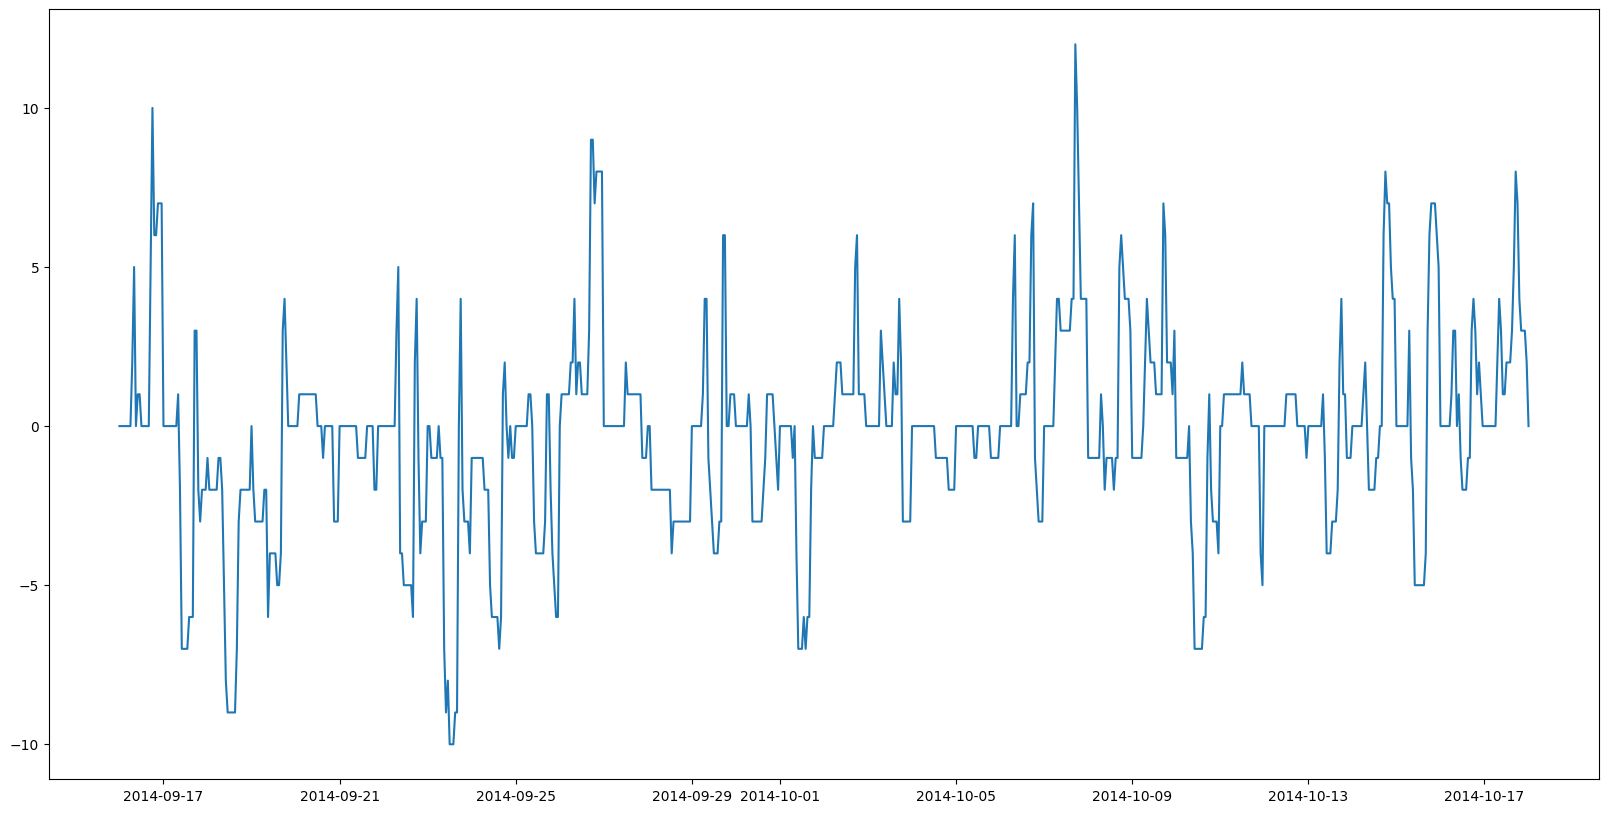

In [ ]:
# demand_cumsumをプロット
# 期間を絞る
df_ = df_target_all.copy()
col = "demand_suplly_cumsum"
station_id = 0
start_date = "2014-09-16"
end_date = "2014-10-18"
df_ = df_[df_["station_id"]==station_id]
df_ = df_[(df_["datetime"] >= start_date) & (df_["datetime"] <= end_date)]
plt.figure(figsize=(20, 10))
plt.plot(df_["datetime"], df_[col])
plt.show()

0

datetime         0
datetime_feat    0
year             0
month            0
day              0
hour             0
weekday          0
holiday          0
dtype: int64
